## **Introduction to Integer Programming and Applications with Julia**

<table>
  <tr>
    <td>Chapter</td>
    <td>1 - Introduction to Integer Programming</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

---

## Exercise 1.1

Suppose there are ten possible locations where health centers could be installed to serve a population. Express the following constraints on which centers can be selected:

$$
x_i=\left\{
    \begin{array}{ll}
        1 & \text{if you select center} \ i \\
        0 & \text{otherwise}
    \end{array}
\right.
$$ 

### a) You cannot select all centers

$$\sum_{i=1}^{10} x_i \le 9$$

### b) At least one center must be selected

$$\sum_{i=1}^{10} x_i \ge 1$$

### c) If center 5 is selected, then center 2 cannot be selected

$$x_2 + x_5 \le 1$$

### d) Center 10 can be selected only if center 7 is also selected

$$x_{10} \le x_7$$

### e) Centers 3 and 8 must either both be selected or both not selected

$$x_3 = x_8$$

---

## Exercise 1.2

The following Julia code to solve the Flow Free puzzle using an integer programming model. The code defines a function `solve_flow_free` that takes as input a dataset containing the terminal points of the puzzle and the grid size. The function creates a JuMP model, defines binary variables for cell colors and edge selections, and sets up constraints to ensure valid solutions. Finally, it solves the model and visualizes the solution using a utility function.

In [1]:
using JuMP       # Modeling language
using HiGHS      # Solver 
using CSV        # Data handling
using DataFrames # Data handling

# Utility function to draw solution
include("utils/flowfree_utils.jl")

# Function to solve the Flow Free problem
function solve_flow_free(data; grid_size = 5)

  total_cells = grid_size^2
  total_colors = maximum(data.color)
  total_directions = 4  # (up, down, right, left)

  # Location and color of terminal points on board
  t = zeros(Int64, total_cells)
  for row in eachrow(data)
    id = coordinates_to_id(row.X, row.Y, grid_size)
    t[id] = row.color
  end

  # Ranges for variables
  T = 1:total_cells
  C = 1:total_colors
  D = 1:total_directions

  # Create model
  model = JuMP.Model(HiGHS.Optimizer)

  # Silent mode (solver output is not printed)
  JuMP.set_silent(model)

  # Current activate color in the cell
  @variable(model, cell_color[i in T, k in C], Bin)

  # Neighbor cells connected (up, down, right, left)
  @variable(model, edge_selected[i in T, j in D], Bin)

  # Neighbor cells color  
  @variable(model, edge_color[i in T, j in D, k in C], Bin)

  # Objective: Maximize the sum of the number of cells connected by color
  @objective(model, Max, sum(edge_color[i,j,k] for i in T, 
                                                   j in D, 
                                                   k in C))

  ################################################
  # Creation of type 1 constraints: cell coverage
  ################################################
  for i in T
    if t[i] != 0
      # For terminal cells, only one edge can be selected
      @constraint(model, 
        sum(edge_selected[i,j] for j in D) == 1
      )
    else
      # For non-terminal cells, two edges must be selected
      @constraint(model,
        sum(edge_selected[i,j] for j in D) == 2
      )
    end
  end

  #####################################
  # Creation of type 2 constraints: 
  #    Limit edge Constraints (each edge can only have 1 color)
  # Logic:
  #   a) Blocking the creation of color variables to 
  #      ends not allocated (edge_selected[i,j] == 0)
  #   b) Allows only one color on the ends that are 
  #      allocated (if edge_selected[i,j] == 1, then 
  #      sum (edge_color ijk) <= 1)
  #####################################
  for i in T
    for j in D
      @constraint(model, 
        sum(edge_color[i,j,k] for k in C) <= edge_selected[i,j]
      )
    end
  end

  #####################################
  # Creation of type 3 constraints: Horizontal Connectivity
  # Note: it was not necessary to treat the horizontal ends
  # of the corners of the board, because they will be set to
  # zero by other restrictions (those of type 5).
  # Remembering that:
  # 1 - up
  # 2 - down
  # 3 - right
  # 4 - left
  #####################################
  for i in 1:(total_cells-1)
    for k in C
      # Connects the right edge of cell to the
      # left edge of the next cell
      @constraint(model, 
        edge_color[i,3,k] == edge_color[i+1,4,k]
      )
    end
  end

  ########################################################
  # Creation of type 4 constraints: Vertical Connectivity
  ########################################################
  for i in 1:(total_cells-grid_size)
    for k in C
      # Connects the bottom edge of cell to the top
      # edge of the cell below
      @constraint(model, 
        edge_color[i,2,k] == edge_color[i+grid_size,1,k]
      )
    end
  end

  #################################################################
  # Creation of type 5 constraints: Boundary Edges (extreme nodes)
  #################################################################

  # Top of the board: north end of cells must be disabled
  for i in 1:grid_size
    @constraint(model, edge_selected[i,1] == 0)
  end

  # Bottom of the board: south end of cells must be disabled
  for i in (total_cells-grid_size+1):total_cells
    @constraint(model, edge_selected[i,2] == 0)
  end

  # Right part of board: east end of cells must be turned off
  for i in grid_size:grid_size:total_cells
    @constraint(model, edge_selected[i,3] == 0)
  end

  # Left part of board: left end of cells must be turned off
  for i in 1:grid_size:(total_cells-grid_size+1)
    @constraint(model, edge_selected[i,4] == 0)
  end

  #################################################################
  # Creation of type 6 constraints: Single color in Terminal Cells
  #################################################################
  for i in T
    if t[i] != 0
      for k in C
        if k == t[i]
          @constraint(model,sum(edge_color[i,j,k] for j in D) == 1)
          @constraint(model,cell_color[i,k] == 1) 
        else
          @constraint(model,sum(edge_color[i,j,k] for j in D) == 0)
        end
      end
    end
  end

  ######################################################
  # Creation of type 7 constraints: Same color per cell 
  # & Pick 1 constraints
  ######################################################

  # Each cell can only have one color
  for i in T
    @constraint(model, sum(cell_color[i,k] for k in C) == 1)    
  end

  ######################################################
  # The sum of the cell border color indication variables
  # must be equal to 2 or equal to zero for each color
  #  a) Will be equal to 2 if that color is activated 
  #     in the cell, that is, the variable p will be 1 
  #     (that's why the restriction applies 2*p[cell,color], 
  #     which will be equal to 2)
  #  b) Will be zero if that color is not enabled in the
  #     cell (and therefore 2*p[cell,color], which will equal 0)
  ######################################################
  for i in T
    if t[i] == 0
      for k in C          
        @constraint(model, 
          sum(edge_color[i,j,k] for j in D) == 2 * cell_color[i,k]
        )                           
        end
      end
  end

  # Solve the model
  JuMP.optimize!(model)

  # Get values of the variables (color of the activated edge)
  edge_color_opt = JuMP.value.(edge_color)

  # Display the board results
  p = draw_free_flow_solution(grid_size, data, edge_color_opt)

  # Display the solution
  display(p)
end

solve_flow_free (generic function with 1 method)

### a) Solve using the dataset flowfree5_1.csv

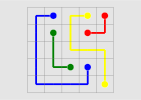

In [2]:
# Load data
data = CSV.read("data/flowfree5_1.csv", DataFrame)

# Solve the problem and display the solution
solve_flow_free(data, grid_size = 5)

### b) Solve using the dataset flowfree5_2.csv

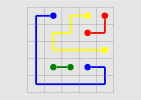

In [3]:
# Load data
data = CSV.read("data/flowfree5_2.csv", DataFrame)

# Solve the problem and display the solution
solve_flow_free(data, grid_size = 5)

### c) Solve using the dataset flowfree6_1.csv

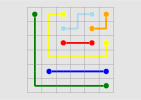

In [4]:
# Load data
data = CSV.read("data/flowfree6_1.csv", DataFrame)

# Solve the problem and display the solution
solve_flow_free(data, grid_size = 6)